In [14]:
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [105]:
device = 'mps'

# Vision

In [2]:
df = pd.read_csv("/Users/animeshsingh/Desktop/Datasets/Fashion_MNIST/fashion-mnist_train.csv")
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


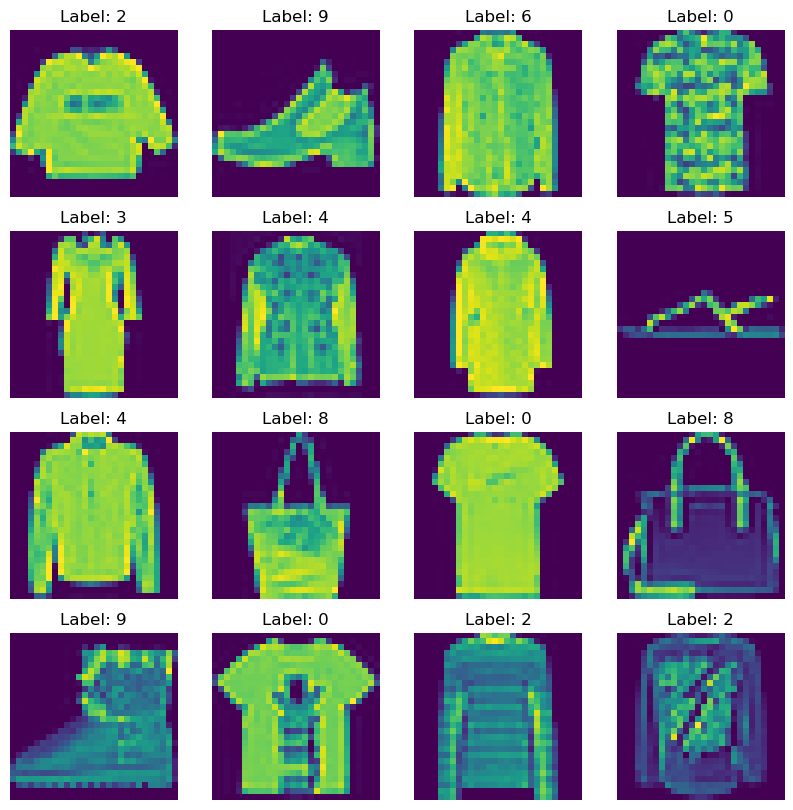

In [9]:
fig, axes = plt.subplots(4, 4, figsize=(10, 10))

# first 16 images from the dataset
for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)  # Reshape to 28x28
    ax.imshow(img)  # Display in grayscale
    ax.axis('off')  # Remove axis for a cleaner look
    ax.set_title(f"Label: {df.iloc[i, 0]}")  # Show the label

plt.show()

In [10]:
X = df.iloc[:,1:].values
y = df.iloc[:,0].values

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 25)

In [41]:
from torchvision.transforms import transforms

custom_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225])
])

In [91]:
class datalao(Dataset):
    def __init__(self, X, y, transform):
        self.X = X
        self.y = y
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        image = self.X[idx].reshape(28,28)
        image = image.astype(np.uint8)
        image = np.stack([image] * 3, axis = -1)
        image = Image.fromarray(image)
        image = self.transform(image)
        return image, torch.tensor(self.y[idx], dtype = torch.long)

In [92]:
train_data = datalao(X_train, y_train, transform = custom_transform)
test_data = datalao(X_test, y_test, transform = custom_transform)

In [93]:
train_load = DataLoader(train_data, batch_size = 48, shuffle = True)
test_load = DataLoader(test_data, batch_size = 48, shuffle = False)

In [94]:
import torchvision.models as models
vgg = models.vgg16(pretrained = True)

/opt/anaconda3/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [95]:
vgg

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [96]:
for param in vgg.features.parameters():
    param.requires_grad = False

In [97]:
vgg.classifier

Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=1000, bias=True)
)

In [108]:
vgg.classifier = nn.Sequential(
    nn.Linear(25088, 1024),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(1024, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, 10)
)

In [109]:
vgg = vgg.to(device)

In [110]:
vgg

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [115]:
lr = 0.0001
epochs = 5

In [116]:
crit = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(vgg.classifier.parameters(), lr = lr)

In [117]:
for epoch in range(epochs):
    tot_loss = 0
    for batch_X, batch_y in train_load:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        outputs = vgg(batch_X)
        loss = crit(outputs, batch_y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        tot_loss += loss.item()
    avg_loss = tot_loss / len(train_load)
    print(f'epoch: {epochs}, loss: {avg_loss}')

epoch: 5, loss: 0.04167122387472773
epoch: 5, loss: 0.0323576132091257
epoch: 5, loss: 0.02765836687592673
epoch: 5, loss: 0.024004167297112872
epoch: 5, loss: 0.02402656156876037


In [130]:
tot = 0
correct = 0

with torch.no_grad():
    for batch_X, batch_y in test_load:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        outputs = vgg(batch_X)
        classs = outputs.argmax(dim = 1)
        correct += (classs == batch_y).sum().item()
        tot += len(batch_X)

print(correct / tot)

0.9216666666666666


# Language

In [182]:
from datasets import load_dataset
dataset = load_dataset("stanfordnlp/sst2")

In [183]:
dataset = dataset['train']

In [140]:
from transformers import AutoModel, AutoTokenizer
model = AutoModel.from_pretrained("prajjwal1/bert-tiny", dtype = "auto")
tokenizer = AutoTokenizer.from_pretrained("prajjwal1/bert-tiny", dtype = "auto")

config.json:   0%|          | 0.00/285 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/17.8M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/17.7M [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

In [141]:
model

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 128, padding_idx=0)
    (position_embeddings): Embedding(512, 128)
    (token_type_embeddings): Embedding(2, 128)
    (LayerNorm): LayerNorm((128,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-1): 2 x BertLayer(
        (attention): BertAttention(
          (self): BertSdpaSelfAttention(
            (query): Linear(in_features=128, out_features=128, bias=True)
            (key): Linear(in_features=128, out_features=128, bias=True)
            (value): Linear(in_features=128, out_features=128, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=128, out_features=128, bias=True)
            (LayerNorm): LayerNorm((128,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)


In [179]:
help(model.forward)

Help on method forward in module transformers.models.bert.modeling_bert:

forward(
    input_ids: Optional[torch.Tensor] = None,
    attention_mask: Optional[torch.Tensor] = None,
    token_type_ids: Optional[torch.Tensor] = None,
    position_ids: Optional[torch.Tensor] = None,
    head_mask: Optional[torch.Tensor] = None,
    inputs_embeds: Optional[torch.Tensor] = None,
    encoder_hidden_states: Optional[torch.Tensor] = None,
    encoder_attention_mask: Optional[torch.Tensor] = None,
    past_key_values: Optional[transformers.cache_utils.Cache] = None,
    use_cache: Optional[bool] = None,
    output_attentions: Optional[bool] = None,
    output_hidden_states: Optional[bool] = None,
    return_dict: Optional[bool] = None,
    cache_position: Optional[torch.Tensor] = None
) -> Union[tuple[torch.Tensor], transformers.modeling_outputs.BaseModelOutputWithPoolingAndCrossAttentions] method of transformers.models.bert.modeling_bert.BertModel instance
    The [`BertModel`] forward method, 

In [185]:
print(f'sentence: {dataset["sentence"][0]}')
tokenizer(dataset["sentence"][0])

sentence: hide new secretions from the parental units 


{'input_ids': [101, 5342, 2047, 3595, 8496, 2013, 1996, 18643, 3197, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

In [186]:
tokenizer("hello")

{'input_ids': [101, 7592, 102], 'token_type_ids': [0, 0, 0], 'attention_mask': [1, 1, 1]}

In [187]:
tokens = tokenizer.convert_ids_to_tokens([101, 7592, 102])
tokens

['[CLS]', 'hello', '[SEP]']

In [174]:
def tok_func(data):
    return tokenizer(data['sentence'])

tok_dataset = dataset.map(tok_func)

Map:   0%|          | 0/67349 [00:00<?, ? examples/s]

In [184]:
dataset

Dataset({
    features: ['idx', 'sentence', 'label'],
    num_rows: 67349
})

In [243]:
class datalao(Dataset):
    def __init__(self, sentence, labels, tokenizer):
        # self.sentence = sentence
        self.encodings = tokenizer(
            sentence,
            truncation = True,
            max_length = 100,
            padding = True
        )
        self.labels = labels
        # self.tokenizer = tokenizer

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": torch.tensor(self.encodings["input_ids"][idx]),
            "attention_mask": torch.tensor(self.encodings["attention_mask"][idx]),
            "labels": torch.tensor(self.labels[idx], dtype = torch.long)
        }

In [244]:
train_data = datalao(dataset["sentence"], dataset["label"], tokenizer)

In [245]:
train_data[0]

{'input_ids': tensor([  101,  5342,  2047,  3595,  8496,  2013,  1996, 18643,  3197,   102,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0]),
 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 'labels': tensor(0)}

In [246]:
train_load = DataLoader(train_data, batch_size = 128, shuffle = True)

In [215]:
from transformers import AutoModelForSequenceClassification
model_class = AutoModelForSequenceClassification.from_pretrained("prajjwal1/bert-tiny", num_labels = 2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at prajjwal1/bert-tiny and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [216]:
model_class

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 128, padding_idx=0)
      (position_embeddings): Embedding(512, 128)
      (token_type_embeddings): Embedding(2, 128)
      (LayerNorm): LayerNorm((128,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-1): 2 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=128, out_features=128, bias=True)
              (key): Linear(in_features=128, out_features=128, bias=True)
              (value): Linear(in_features=128, out_features=128, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=128, out_features=128, bias=True)
              (LayerNorm): LayerNorm((128,), eps=1e-1

In [217]:
for param in model_class.parameters():
    param.requires_grad = True

In [251]:
lr = 0.001
epochs = 50

In [219]:
crit = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_class.parameters(), lr = lr)

In [252]:
tot_loss = 0
correct = 0

for epoch in range(epochs):
    tot_loss = 0
    # for batch_encodings, batch_labels in train_load:
    for batch in train_load:
        # outputs = model_class(batch_encodings['input_ids'], batch_encodings['attention_mask'])
        outputs = model_class(batch['input_ids'], batch['attention_mask'])
        loss = crit(outputs.logits, batch['labels'])
        # classs = outputs.argmax(dim = 1)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        tot_loss += loss
    avg_loss = tot_loss/ len(batch['labels'])
    print(f'epoch: {epoch} loss: {avg_loss}')

epoch: 0 loss: 0.7818801403045654
epoch: 1 loss: 0.6635842323303223
epoch: 2 loss: 0.613427460193634
epoch: 3 loss: 0.6139370799064636
epoch: 4 loss: 0.708142876625061
epoch: 5 loss: 0.5468312501907349
epoch: 6 loss: 0.5756074786186218
epoch: 7 loss: 0.5498356223106384
epoch: 8 loss: 0.5280338525772095
epoch: 9 loss: 0.44558942317962646
epoch: 10 loss: 0.44556736946105957
epoch: 11 loss: 0.4771308898925781
epoch: 12 loss: 0.4568009674549103
epoch: 13 loss: 0.3919520974159241
epoch: 14 loss: 0.6026952266693115
epoch: 15 loss: 0.40435269474983215
epoch: 16 loss: 0.3368223011493683
epoch: 17 loss: 0.2762365937232971
epoch: 18 loss: 0.3241007328033447
epoch: 19 loss: 0.3029092252254486
epoch: 20 loss: 0.3419843912124634
epoch: 21 loss: 0.3399553894996643
epoch: 22 loss: 0.34230244159698486
epoch: 23 loss: 0.3083256483078003
epoch: 24 loss: 0.26014605164527893
epoch: 25 loss: 0.26647520065307617
epoch: 26 loss: 0.270327091217041
epoch: 27 loss: 0.2774518132209778
epoch: 28 loss: 0.356629133

In [ ]:
model_class.save_pretrained("sentiment_tiny_bert")